In [1]:
! pip install networkx
! pip install matplotlib

node degree clustering
0 4 0.16666666666666666
1 4 0
2 3 0
3 4 0
4 4 0.16666666666666666
5 2 0
6 1 0
7 3 0.3333333333333333
8 1 0
9 6 0.06666666666666667
10 4 0.16666666666666666
11 2 0
12 5 0.3
13 2 0
14 3 0
15 4 0.3333333333333333
16 1 0
17 1 0
18 1 0
19 5 0.2

the adjacency list
0 7 3 15 2
1 3 13 18 4
2 19 17
3 19 5
4 10 12 14
5 9
6 14
7 10 15
8 11
9 16 14 19 12 11
10 12 13
11
12 19 15
13
14
15 19
16
17
18
19


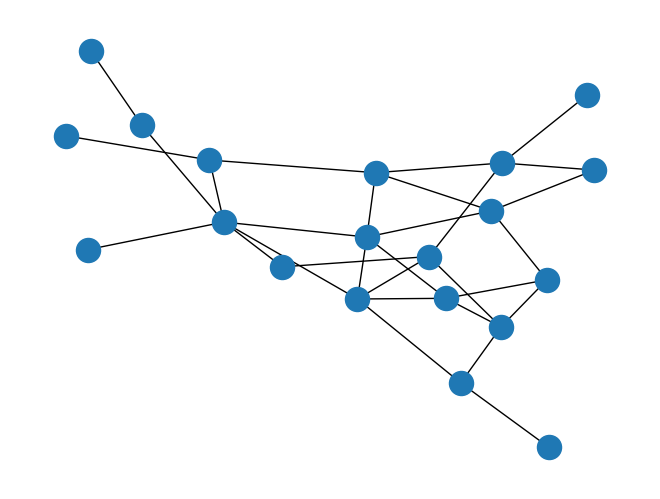

In [16]:
import matplotlib.pyplot as plt
import networkx as nx

n = 20  # 10 nodes
m = 30  # 20 edges
seed = 20160  # seed random number generators for reproducibility

# Use seed for reproducibility
# G = nx.gnm_random_graph(n, m, seed=seed)

G = nx.gnm_random_graph(n, m)

# some properties
print("node degree clustering")
for v in nx.nodes(G):
    print(f"{v} {nx.degree(G, v)} {nx.clustering(G, v)}")

print()
print("the adjacency list")
for line in nx.generate_adjlist(G):
    print(line)

pos = nx.spring_layout(G, seed=seed)  # Seed for reproducible layout
nx.draw(G, pos=pos)
plt.show()

In [29]:
def coloring_conflicts (G, coloring):
    conflicts = 0
    # Use the edge set to check for conflicts
    for u, v in G.edges():
        # print(f"edge ({u}, {v}) has colors {coloring[u]} and {coloring[v]}")
        if coloring[u] == coloring[v]:
            conflicts += 1
    return conflicts

## Testing out coloring using built in greedy algorithm

In [17]:
def graph_coloring(G):
    # Use a greedy coloring algorithm
    coloring = nx.coloring.greedy_color(G, strategy='largest_first')
    return coloring

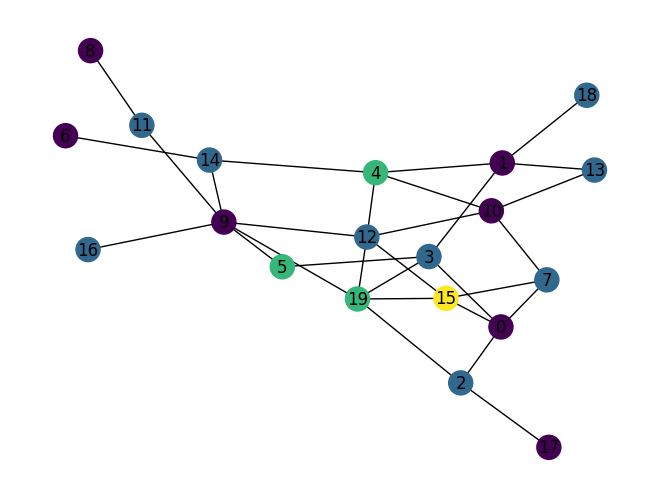

In [ ]:
coloring = graph_coloring(G)
node_colors = [coloring[node] for node in G.nodes()]
nx.draw(G, pos=pos, node_color=node_colors, with_labels=True)
plt.show() 

### Check for conflicts

In [22]:
conflicts = coloring_conflicts(G, coloring)
conflicts

edge (0, 7) has colors 0 and 1
edge (0, 3) has colors 0 and 1
edge (0, 15) has colors 0 and 3
edge (0, 2) has colors 0 and 1
edge (1, 3) has colors 0 and 1
edge (1, 13) has colors 0 and 1
edge (1, 18) has colors 0 and 1
edge (1, 4) has colors 0 and 2
edge (2, 19) has colors 1 and 2
edge (2, 17) has colors 1 and 0
edge (3, 19) has colors 1 and 2
edge (3, 5) has colors 1 and 2
edge (4, 10) has colors 2 and 0
edge (4, 12) has colors 2 and 1
edge (4, 14) has colors 2 and 1
edge (5, 9) has colors 2 and 0
edge (6, 14) has colors 0 and 1
edge (7, 10) has colors 1 and 0
edge (7, 15) has colors 1 and 3
edge (8, 11) has colors 0 and 1
edge (9, 16) has colors 0 and 1
edge (9, 14) has colors 0 and 1
edge (9, 19) has colors 0 and 2
edge (9, 12) has colors 0 and 1
edge (9, 11) has colors 0 and 1
edge (10, 12) has colors 0 and 1
edge (10, 13) has colors 0 and 1
edge (12, 19) has colors 1 and 2
edge (12, 15) has colors 1 and 3
edge (15, 19) has colors 3 and 2


0

## Randomly assigning colors

In [26]:

import random
      
def random_coloring(G):
    coloring = {}
    for node in G.nodes():
        coloring[node] = random.randint(0, n-1)  # Random color from 0 to n-1
    return coloring

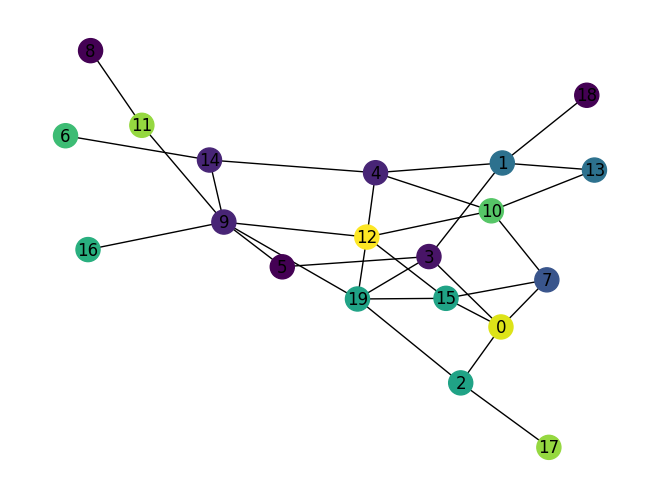

In [27]:
coloring = random_coloring(G)
node_colors = [coloring[node] for node in G.nodes()]
nx.draw(G, pos=pos, node_color=node_colors, with_labels=True)
plt.show()

In [30]:
conflicts = coloring_conflicts(G, coloring)
print(f"Number of conflicts: {conflicts}")

Number of conflicts: 5


Trial 1: Number of conflicts: 4
Trial 2: Number of conflicts: 1
Trial 3: Number of conflicts: 2
Trial 4: Number of conflicts: 1
Trial 5: Number of conflicts: 1
Trial 6: Number of conflicts: 0
Trial 7: Number of conflicts: 2
Trial 8: Number of conflicts: 2
Trial 9: Number of conflicts: 2
Trial 10: Number of conflicts: 1
Trial 11: Number of conflicts: 3
Trial 12: Number of conflicts: 3
Trial 13: Number of conflicts: 2
Trial 14: Number of conflicts: 2
Trial 15: Number of conflicts: 1
Trial 16: Number of conflicts: 1
Trial 17: Number of conflicts: 1
Trial 18: Number of conflicts: 2
Trial 19: Number of conflicts: 1
Trial 20: Number of conflicts: 1
Trial 21: Number of conflicts: 1
Trial 22: Number of conflicts: 1
Trial 23: Number of conflicts: 1
Trial 24: Number of conflicts: 4
Trial 25: Number of conflicts: 0
Trial 26: Number of conflicts: 1
Trial 27: Number of conflicts: 2
Trial 28: Number of conflicts: 3
Trial 29: Number of conflicts: 0
Trial 30: Number of conflicts: 5
Trial 31: Number of

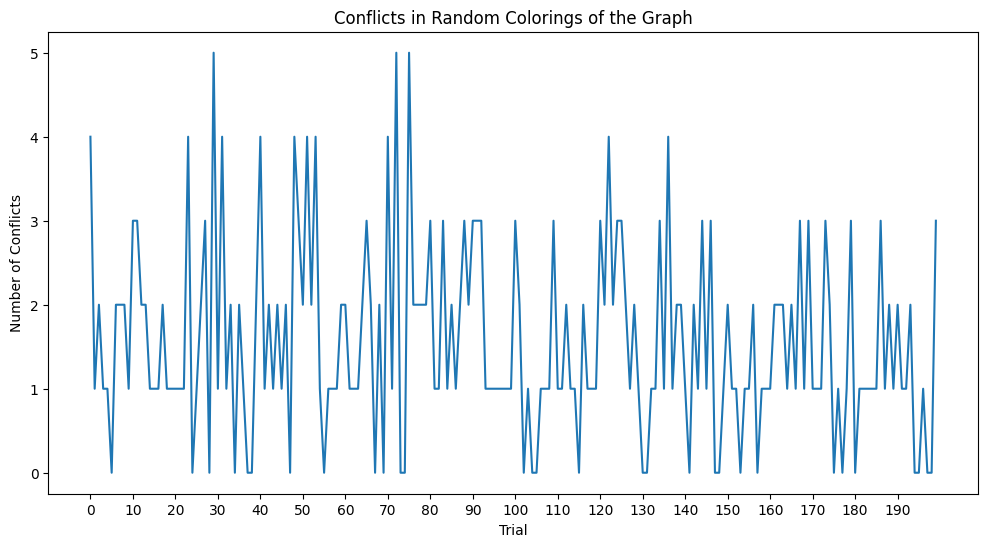

In [41]:

list_of_conflicts = []
for i in range(200):
    multiple_coloring = random_coloring(G)
    node_colors = [coloring[node] for node in G.nodes()]
    conflicts = coloring_conflicts(G, multiple_coloring)
    list_of_conflicts.append(conflicts)
    print(f"Trial {i+1}: Number of conflicts: {conflicts}")


plt.figure(figsize=(12, 6))
plt.plot(list_of_conflicts)
plt.xlabel('Trial')
plt.ylabel('Number of Conflicts')
plt.title('Conflicts in Random Colorings of the Graph')
plt.xticks(range(0, 200, 10))

plt.show()
